In [1]:
import sys
from pathlib import Path
# Add the parent directory to sys.path so we can import synth_extract
sys.path.insert(0, str(Path.cwd().parent)) 

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Category-level status from the discovery workspace.

from contextlib import closing
from pathlib import Path
import sqlite3

import pandas as pd

workspace_candidates = [
    Path.cwd().resolve() / "data" / "discovery_workspace.db",
    Path.cwd().resolve().parent / "data" / "discovery_workspace.db",
]
discovery_db_path = next(
    (path for path in workspace_candidates if path.is_file()),
    None,
)
if discovery_db_path is None:
    searched_paths = "\n".join(f"- {path}" for path in workspace_candidates)
    raise FileNotFoundError(
        "Could not find discovery_workspace.db. Searched:\n"
        f"{searched_paths}"
    )

database_uri = f"{discovery_db_path.as_uri()}?mode=ro"
with closing(sqlite3.connect(database_uri, uri=True, timeout=60)) as conn:
    conn.execute("PRAGMA query_only = ON")
    conn.execute("PRAGMA busy_timeout = 60000")

    available_columns = {
        row[1]
        for row in conn.execute(
            "PRAGMA table_info(polymer_material_papers)"
        )
    }
    required_columns = {"category_class", "pty_no_res"}
    missing_columns = sorted(required_columns - available_columns)
    if missing_columns:
        raise ValueError(
            "polymer_material_papers is missing column(s): "
            + ", ".join(missing_columns)
        )

    category_stats = pd.read_sql_query(
        """
        SELECT
            COALESCE(category_class, '[NULL]') AS category_class,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN pty_no_res IS NOT NULL THEN 1 ELSE 0 END)
                AS completed_rows,
            SUM(CASE WHEN pty_no_res IS NULL THEN 1 ELSE 0 END)
                AS pending_rows
        FROM polymer_material_papers
        GROUP BY category_class
        ORDER BY total_rows DESC, category_class
        """,
        conn,
    )

category_stats["completion_percent"] = (
    100 * category_stats["completed_rows"] / category_stats["total_rows"]
).round(1)
category_stats = pd.concat(
    [
        category_stats,
        pd.DataFrame(
            {
                "category_class": ["TOTAL"],
                "total_rows": [category_stats["total_rows"].sum()],
                "completed_rows": [category_stats["completed_rows"].sum()],
                "pending_rows": [category_stats["pending_rows"].sum()],
                "completion_percent": [
                    round(
                        100
                        * category_stats["completed_rows"].sum()
                        / category_stats["total_rows"].sum(),
                        1,
                    )
                ],
            }
        ),
    ],
    ignore_index=True,
)

print(f"Database: {discovery_db_path}")
category_stats


Database: /Users/kevinge/Work/Data Extraction/synth_extract/data/discovery_workspace.db


,category_class,total_rows,completed_rows,pending_rows,completion_percent
0,polymer_composite_formulation,142535,141580,955,99.3
1,polymer_synthesis,79549,78785,764,99.0
2,polymer_modification_combination,51107,50701,406,99.2
3,TOTAL,273191,271066,2125,99.2


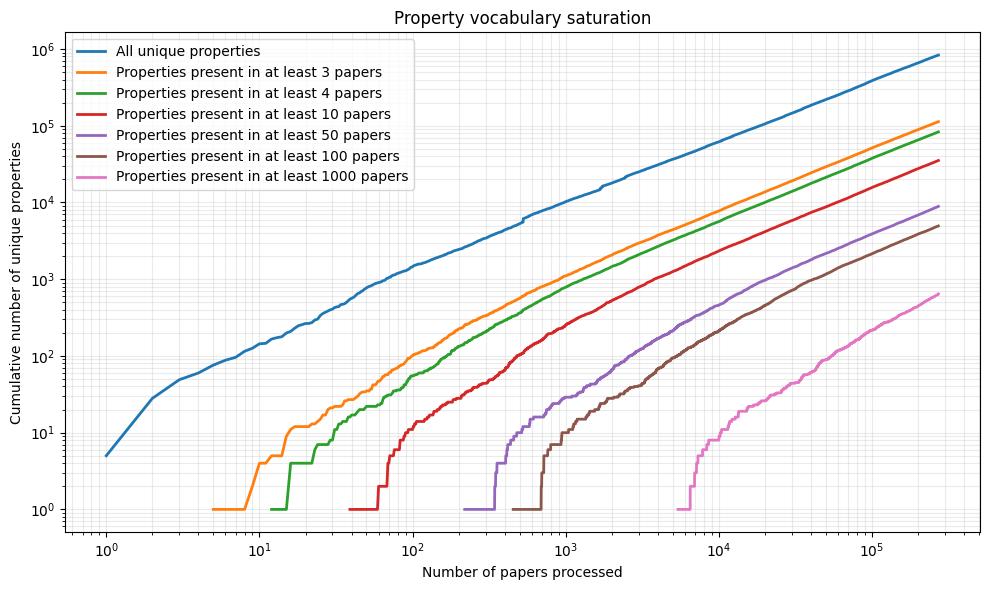

Papers included: 271,066 | Random seed: 42


,papers_processed,cumulative_unique_properties,cumulative_properties_in_at_least_3_papers,cumulative_properties_in_at_least_4_papers,cumulative_properties_in_at_least_10_papers,cumulative_properties_in_at_least_50_papers,cumulative_properties_in_at_least_100_papers,cumulative_properties_in_at_least_1000_papers
271062,271062,835030,113166,83170,35260,8901,4939,644
271063,271063,835036,113167,83171,35261,8901,4939,644
271064,271064,835037,113167,83171,35261,8901,4939,644
271065,271065,835043,113167,83171,35261,8901,4939,644
271066,271066,835043,113167,83171,35262,8901,4939,644


In [5]:
# Vocabulary saturation / species accumulation curves.

from collections import Counter
from contextlib import closing
import json
import random
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

paper_count_thresholds = (3, 4, 10, 50, 100, 1000)
random_seed = 42
database_uri = f"{discovery_db_path.as_uri()}?mode=ro"
with closing(sqlite3.connect(database_uri, uri=True, timeout=60)) as conn:
    conn.execute("PRAGMA query_only = ON")
    conn.execute("PRAGMA busy_timeout = 60000")
    property_rows = conn.execute(
        """
        SELECT paper_uid, pty_no_res
        FROM polymer_material_papers
        WHERE pty_no_res IS NOT NULL
        ORDER BY paper_uid
        """
    ).fetchall()

# Shuffle before insertion because dictionaries retain insertion order.
paper_order_rng = random.Random(random_seed)
paper_order_rng.shuffle(property_rows)

property_json_by_uid: dict[str, list[str]] = {}
for paper_uid, property_json in property_rows:
    try:
        properties = json.loads(property_json)
    except (TypeError, json.JSONDecodeError) as exc:
        raise ValueError(
            f"Invalid pty_no_res JSON for paper {paper_uid!r}"
        ) from exc

    if not isinstance(properties, list) or not all(
        isinstance(property_name, str) for property_name in properties
    ):
        raise ValueError(
            f"pty_no_res for paper {paper_uid!r} must be a JSON list of strings"
        )
    property_json_by_uid[str(paper_uid)] = properties

if not property_json_by_uid:
    raise ValueError(
        "No non-NULL pty_no_res values were found; run discovery first."
    )

paper_numbers = [0]
cumulative_unique_properties = [0]
cumulative_properties_by_threshold = {
    threshold: [0] for threshold in paper_count_thresholds
}
seen_properties: set[str] = set()
property_paper_counts: Counter[str] = Counter()
properties_by_threshold = {
    threshold: 0 for threshold in paper_count_thresholds
}

for paper_number, properties in enumerate(
    property_json_by_uid.values(),
    start=1,
):
    # Repeated spans within one paper count once toward paper prevalence.
    properties_in_paper = set(properties)
    seen_properties.update(properties_in_paper)
    for property_name in properties_in_paper:
        property_paper_counts[property_name] += 1
        new_count = property_paper_counts[property_name]
        if new_count in properties_by_threshold:
            properties_by_threshold[new_count] += 1

    paper_numbers.append(paper_number)
    cumulative_unique_properties.append(len(seen_properties))
    for threshold in paper_count_thresholds:
        cumulative_properties_by_threshold[threshold].append(
            properties_by_threshold[threshold]
        )

# Omit zero-valued points from the log-log rendering.
plot_paper_numbers = paper_numbers[1:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    plot_paper_numbers,
    cumulative_unique_properties[1:],
    linewidth=2,
    label="All unique properties",
)
for threshold in paper_count_thresholds:
    ax.plot(
        plot_paper_numbers,
        [
            value if value > 0 else float("nan")
            for value in cumulative_properties_by_threshold[threshold][1:]
        ],
        linewidth=2,
        label=f"Properties present in at least {threshold} papers",
    )

ax.set_xlabel("Number of papers processed")
ax.set_ylabel("Cumulative number of unique properties")
ax.set_title("Property vocabulary saturation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
plt.show()

property_saturation_data = {
    "papers_processed": paper_numbers,
    "cumulative_unique_properties": cumulative_unique_properties,
}
for threshold in paper_count_thresholds:
    property_saturation_data[
        f"cumulative_properties_in_at_least_{threshold}_papers"
    ] = cumulative_properties_by_threshold[threshold]

property_saturation_curve = pd.DataFrame(property_saturation_data)

print(
    f"Papers included: {len(property_json_by_uid):,} | "
    f"Random seed: {random_seed}"
)
property_saturation_curve.tail()


In [ ]:
c = 0
for paper_number, properties in enumerate(
    property_json_by_uid.values(),
    start=1,
):
    if "viscosity" in properties and "Mn" in properties and "Mw" in properties:
        c += 1

print(c)

In [ ]:
# Most prevalent properties by number of papers.

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

top_n_properties = 50
if not property_paper_counts:
    raise ValueError(
        "property_paper_counts is empty; run the saturation cell first."
    )

top_properties = pd.DataFrame(
    property_paper_counts.most_common(top_n_properties),
    columns=["property_name", "paper_count"],
)

fig, ax = plt.subplots(figsize=(11, 8))
plot_data = top_properties.iloc[::-1]
bars = ax.barh(
    plot_data["property_name"],
    plot_data["paper_count"],
    color="tab:blue",
)
ax.bar_label(bars, padding=3, fmt="%d")
ax.set_xlabel("Number of papers")
ax.set_ylabel("Property name")
ax.set_title(f"Top {top_n_properties} properties by paper prevalence")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="x", alpha=0.25)
ax.margins(x=0.12)
fig.tight_layout()
plt.show()


In [ ]:
property_paper_counts

In [ ]:
# Property vocabulary saturation within each paper category.

from collections import Counter
from contextlib import closing
import json
import random
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

def build_category_saturation_curve(
    conn: sqlite3.Connection,
    category: str,
    thresholds: tuple[int, ...],
    seed: int | None,
) -> pd.DataFrame:
    paper_numbers = [0]
    cumulative_unique_properties = [0]
    cumulative_properties_by_threshold = {
        threshold: [0] for threshold in thresholds
    }
    property_counts: Counter[str] = Counter()
    properties_by_threshold = {threshold: 0 for threshold in thresholds}

    rows = conn.execute(
        """
        SELECT paper_uid, pty_no_res
        FROM polymer_material_papers
        WHERE category_class = ?
          AND pty_no_res IS NOT NULL
        ORDER BY paper_uid
        """,
        (category,),
    ).fetchall()
    # Use a distinct, reproducible random order for each category.
    category_seed = None if seed is None else f"{seed}:{category}"
    paper_order_rng = random.Random(category_seed)
    paper_order_rng.shuffle(rows)

    for paper_number, (paper_uid, property_json) in enumerate(rows, start=1):
        try:
            properties = json.loads(property_json)
        except (TypeError, json.JSONDecodeError) as exc:
            raise ValueError(
                f"Invalid pty_no_res JSON for paper {paper_uid!r}"
            ) from exc
        if not isinstance(properties, list) or not all(
            isinstance(property_name, str) for property_name in properties
        ):
            raise ValueError(
                f"pty_no_res for paper {paper_uid!r} must be a JSON list of strings"
            )

        # A property contributes at most once per paper.
        for property_name in set(properties):
            property_counts[property_name] += 1
            new_count = property_counts[property_name]
            if new_count in properties_by_threshold:
                properties_by_threshold[new_count] += 1

        paper_numbers.append(paper_number)
        cumulative_unique_properties.append(len(property_counts))
        for threshold in thresholds:
            cumulative_properties_by_threshold[threshold].append(
                properties_by_threshold[threshold]
            )

    curve_data = {
        "papers_processed": paper_numbers,
        "cumulative_unique_properties": cumulative_unique_properties,
    }
    for threshold in thresholds:
        curve_data[
            f"cumulative_properties_in_at_least_{threshold}_papers"
        ] = cumulative_properties_by_threshold[threshold]
    return pd.DataFrame(curve_data)


category_thresholds = tuple(paper_count_thresholds)
category_random_seed = 42
database_uri = f"{discovery_db_path.as_uri()}?mode=ro"
with closing(sqlite3.connect(database_uri, uri=True, timeout=60)) as conn:
    conn.execute("PRAGMA query_only = ON")
    conn.execute("PRAGMA busy_timeout = 60000")
    categories = [
        row[0]
        for row in conn.execute(
            """
            SELECT DISTINCT category_class
            FROM polymer_material_papers
            WHERE category_class IS NOT NULL
              AND pty_no_res IS NOT NULL
            ORDER BY category_class
            """
        )
    ]
    if len(categories) != 3:
        raise ValueError(
            f"Expected 3 categories with results, found {len(categories)}: "
            f"{categories}"
        )

    category_saturation_curves = {
        category: build_category_saturation_curve(
            conn,
            category,
            category_thresholds,
            seed=category_random_seed,
        )
        for category in categories
    }

fig, axes = plt.subplots(
    1,
    len(categories),
    figsize=(19, 6),
    sharey=True,
)
for ax, category in zip(axes, categories):
    curve = category_saturation_curves[category]
    plot_curve = curve.iloc[1:]
    ax.plot(
        plot_curve["papers_processed"],
        plot_curve["cumulative_unique_properties"].where(
            plot_curve["cumulative_unique_properties"] > 0
        ),
        linewidth=2,
        label="All unique properties",
    )
    for threshold in category_thresholds:
        column = f"cumulative_properties_in_at_least_{threshold}_papers"
        ax.plot(
            plot_curve["papers_processed"],
            plot_curve[column].where(plot_curve[column] > 0),
            linewidth=2,
            label=f"At least {threshold} papers",
        )

    paper_count = int(curve["papers_processed"].iloc[-1])
    ax.set_title(
        f"{category.replace('_', ' ').title()}\n"
        f"({paper_count:,} papers)"
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(alpha=0.25, which="both")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
)
fig.supxlabel("Number of papers processed")
fig.supylabel("Cumulative number of unique properties")
fig.suptitle("Property vocabulary saturation by category", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()


In [ ]:
# Most prevalent properties within each category.

from collections import Counter
from contextlib import closing
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

top_n_properties_per_category = 50
database_uri = f"{discovery_db_path.as_uri()}?mode=ro"
top_properties_by_category: dict[str, pd.DataFrame] = {}

with closing(sqlite3.connect(database_uri, uri=True, timeout=60)) as conn:
    conn.execute("PRAGMA query_only = ON")
    conn.execute("PRAGMA busy_timeout = 60000")
    barplot_categories = [
        row[0]
        for row in conn.execute(
            """
            SELECT DISTINCT category_class
            FROM polymer_material_papers
            WHERE category_class IS NOT NULL
              AND pty_no_res IS NOT NULL
            ORDER BY category_class
            """
        )
    ]
    if len(barplot_categories) != 3:
        raise ValueError(
            f"Expected 3 categories with results, found "
            f"{len(barplot_categories)}: {barplot_categories}"
        )

    fig, axes = plt.subplots(
        1,
        len(barplot_categories),
        figsize=(24, 10),
        sharey=False,
    )

    for ax, category in zip(axes, barplot_categories):
        category_property_counts: Counter[str] = Counter()
        rows = conn.execute(
            """
            SELECT paper_uid, pty_no_res
            FROM polymer_material_papers
            WHERE category_class = ?
              AND pty_no_res IS NOT NULL
            ORDER BY paper_uid
            """,
            (category,),
        )
        for paper_uid, property_json in rows:
            try:
                properties = json.loads(property_json)
            except (TypeError, json.JSONDecodeError) as exc:
                raise ValueError(
                    f"Invalid pty_no_res JSON for paper {paper_uid!r}"
                ) from exc
            if not isinstance(properties, list) or not all(
                isinstance(property_name, str)
                for property_name in properties
            ):
                raise ValueError(
                    f"pty_no_res for paper {paper_uid!r} must be a "
                    "JSON list of strings"
                )
            # Repeated spans in one paper contribute once to prevalence.
            category_property_counts.update(set(properties))

        if not category_property_counts:
            raise ValueError(f"No properties found for category {category!r}")

        top_properties = pd.DataFrame(
            category_property_counts.most_common(
                top_n_properties_per_category
            ),
            columns=["property_name", "paper_count"],
        )
        top_properties_by_category[category] = top_properties

        plot_data = top_properties.iloc[::-1]
        bars = ax.barh(
            plot_data["property_name"],
            plot_data["paper_count"],
            color="tab:blue",
        )
        ax.bar_label(bars, padding=3, fmt="%d")
        ax.set_title(
            f"{category.replace('_', ' ').title()}\n"
            f"Top {top_n_properties_per_category} properties"
        )
        ax.set_xlabel("Number of papers")
        ax.set_ylabel("Property name")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis="x", alpha=0.25)
        ax.margins(x=0.15)

fig.suptitle("Most prevalent properties by category", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
